In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("cadata.csv")

In [4]:
df.head()

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,452600.0,8.3252,41.0,880.0,129.0,322.0,126.0,37.88,-122.23
1,358500.0,8.3014,21.0,7099.0,1106.0,2401.0,1138.0,37.86,-122.22
2,352100.0,7.2574,52.0,1467.0,190.0,496.0,177.0,37.85,-122.24
3,341300.0,5.6431,52.0,1274.0,235.0,558.0,219.0,37.85,-122.25
4,342200.0,3.8462,52.0,1627.0,280.0,565.0,259.0,37.85,-122.25


In [5]:
df.shape

(20640, 9)

In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [10]:
df.isnull().sum()

median_house_value    0
median_income         0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
latitude              0
longitude             0
dtype: int64

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='median_house_value', ylabel='Count'>

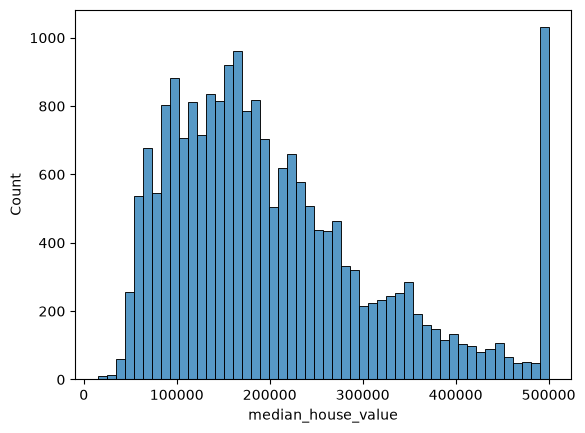

In [12]:
sns.histplot(df.median_house_value, bins = 50)

In [15]:
values_log = np.log1p(df.median_house_value)
values_log

0        13.022766
1        12.789687
2        12.771673
3        12.740520
4        12.743154
           ...    
20635    11.265758
20636    11.252872
20637    11.432810
20638    11.346883
20639    11.400887
Name: median_house_value, Length: 20640, dtype: float64

<Axes: xlabel='median_house_value', ylabel='Count'>

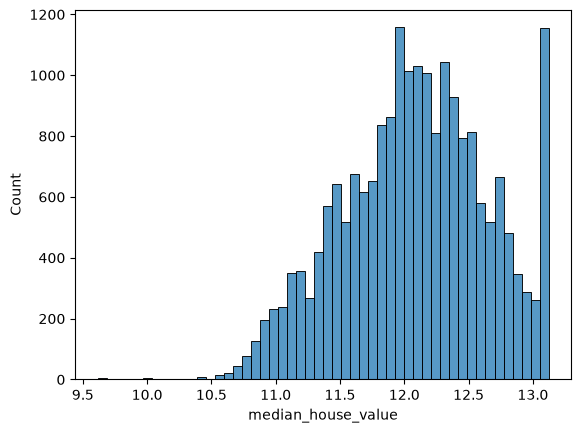

In [16]:
sns.histplot(values_log,bins = 50)

In [19]:
n = len(df)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_val - n_test

In [20]:
n_val, n_test, n_train

(4128, 4128, 12384)

In [21]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

In [22]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val:]]
df_test = df.iloc[idx[n_train+n_val:]]

In [23]:
len(df_train), len(df_val), len(df_test)

(12384, 4128, 4128)

In [24]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [25]:
df_train.head()

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,47700.0,1.6812,25.0,1505.0,367.0,1392.0,359.0,36.06,-119.01
1,45800.0,2.5313,30.0,2943.0,697.0,1565.0,584.0,35.14,-119.46
2,500001.0,3.4801,52.0,3830.0,1142.0,1310.0,963.0,37.80,-122.44
3,218600.0,5.7376,17.0,3051.0,505.0,1705.0,495.0,34.28,-118.72
4,278000.0,3.7250,34.0,2351.0,440.0,1063.0,428.0,36.62,-121.93


In [26]:
y_train = np.log1p(df_train.median_house_value.values)
y_val = np.log1p(df_val.median_house_value.values)
y_test = np.log1p(df_test.median_house_value.values)

In [27]:
del df_train['median_house_value']
del df_val['median_house_value']
del df_test['median_house_value']

In [ ]:
df_train.iloc[10]